In [ ]:
# ============================================================
# PERTEMUAN 4
# LITERASI DATA DAN KECERDASAN ARTIFISIAL
#
# HANDS-ON EXPLORATORY DATA ANALYSIS (EDA) DENGAN PYTHON
#
# Studi Kasus: Analisis Data Karyawan
# Platform   : Google Colab
# ============================================================


# EDA (Exploratory Data Analysis) atau Analisis Data Eksploratif adalah proses
# mengenali, memeriksa, dan memahami data sebelum melakukan analisis lebih lanjut atau membuat model machine learning.
# Kenalan dengan Data

# ============================================================
# TUJUAN PEMBELAJARAN
# ============================================================
#
#
# 1. Menggunakan Pandas untuk membaca dan mengeksplorasi data.
#
# 2. Menghitung dan menginterpretasikan statistik deskriptif.
#
# 3. Membuat visualisasi menggunakan Matplotlib dan Seaborn.
#
# 4. Mengidentifikasi pola dan hubungan antarvariabel.
#
# 5. Mendeteksi potensi anomali menggunakan metode statistik.
#
# 6. Menyusun kesimpulan berdasarkan hasil analisis.
#
#
# ALUR Handson:
#
# Membaca Data
#       |
#       v
# Memahami Struktur Data
#       |
#       v
# Statistik Deskriptif
#       |
#       v
# Visualisasi Data
#       |
#       v
# Analisis Pola dan Hubungan
#       |
#       v
# Deteksi Anomali
#       |
#       v
# Kesimpulan
#
# ============================================================


# ============================================================
# BAGIAN A — PERSIAPAN DATA
#
# CELL 1 — IMPORT LIBRARY DAN GOOGLE DRIVE
#
# Tujuan:
# Mempersiapkan seluruh library yang digunakan selama
# praktikum dan menghubungkan Google Colab dengan Google Drive.
# ============================================================


# Import Pandas
#
# Pandas digunakan untuk:
# - Membaca dataset CSV.
# - Mengelola data dalam bentuk DataFrame.
# - Menghitung statistik deskriptif.
# - Mengelompokkan data.
# - Melakukan eksplorasi data.
import pandas as pd


# Import NumPy
#
# NumPy digunakan untuk:
# - Operasi numerik.
# - Perhitungan matematika.
# - Pengolahan data berbentuk array.
import numpy as np


# Import Matplotlib
#
# Matplotlib digunakan untuk membuat grafik seperti:
# - Histogram.
# - Diagram batang.
# - Scatter plot.
# - Boxplot.
import matplotlib.pyplot as plt


# Import Seaborn
#
# Seaborn merupakan library visualisasi statistik
# yang dibangun di atas Matplotlib.
#
# Library ini memudahkan pembuatan:
# - Histogram.
# - Boxplot.
# - Scatter plot.
# - Heatmap korelasi.
import seaborn as sns


# Import os
#
# Library os digunakan untuk berinteraksi dengan
# sistem operasi, misalnya membuat folder.
import os


# Import Google Drive
#
# Digunakan untuk menghubungkan Google Colab
# dengan penyimpanan Google Drive.
from google.colab import drive


# ============================================================
# PENGATURAN TAMPILAN
# ============================================================


# Mengatur agar Pandas dapat menampilkan seluruh kolom.
pd.set_option('display.max_columns', None)


# Mengatur format tampilan angka desimal.
pd.set_option('display.float_format', '{:,.2f}'.format)


# Mengatur tema visualisasi Seaborn.
sns.set_theme(style='whitegrid')


# ============================================================
# MENGHUBUNGKAN GOOGLE DRIVE
# ============================================================


# Menghubungkan Google Colab dengan Google Drive.
#
# Ketika dijalankan, Google akan meminta izin akses.
drive.mount('/content/drive')


# Menentukan lokasi folder praktikum.
folder_path = '/content/drive/MyDrive/Praktikum_Literasi_Data_AI'


# Membuat folder apabila belum tersedia.
#
# exist_ok=True berarti program tidak menghasilkan error
# apabila folder tersebut sudah ada.
os.makedirs(folder_path, exist_ok=True)


# Menampilkan informasi.
print("✅ Seluruh library berhasil diimpor.")

print("✅ Google Drive berhasil dihubungkan.")

print(f"✅ Folder praktikum: {folder_path}")

Mounted at /content/drive
✅ Seluruh library berhasil diimpor.
✅ Google Drive berhasil dihubungkan.
✅ Folder praktikum: /content/drive/MyDrive/Praktikum_Literasi_Data_AI


In [ ]:
# ============================================================
# BAGIAN A — PERSIAPAN DATA
#
# CELL 2 — MEMBACA DATASET
#
# Tujuan:
# Membaca dataset hasil pembersihan dari pertemuan sebelumnya.
#
# Dataset:
# data_bersih.csv
#
# Dataset merupakan data sintetis karyawan yang berisi:
#
# ID          : Identitas karyawan.
# Nama        : Nama karyawan.
# Umur        : Usia karyawan.
# Pendidikan  : Tingkat pendidikan.
# Kota        : Kota domisili.
# Lama_Kerja  : Pengalaman kerja dalam tahun.
# Gaji        : Penghasilan karyawan.
#
# CATATAN:
#
# Data ini merupakan data sintetis yang dibuat untuk
# keperluan pembelajaran.
#
# Hasil analisis tidak dapat digunakan untuk menyimpulkan
# kondisi tenaga kerja Indonesia secara umum.
# ============================================================


# Menentukan lokasi file di Google Drive.
#
# os.path.join() digunakan untuk menggabungkan
# alamat folder dan nama file.
file_path = os.path.join(
    folder_path,
    'data_bersih.csv'
)


# Memeriksa apakah file tersedia.
#
# Jika file tidak ditemukan, program menampilkan error.
assert os.path.exists(file_path), (
    f"File tidak ditemukan: {file_path}"
)


# Membaca CSV menjadi DataFrame.
#
# pd.read_csv() membaca file CSV.
#
# Hasil pembacaan disimpan dalam variabel df.
df = pd.read_csv(file_path)


# Menampilkan informasi.
print("✅ Dataset berhasil dimuat.")

print(f"Lokasi file: {file_path}")


# Menampilkan lima baris pertama.
#
# head() digunakan untuk melihat contoh isi dataset.
display(df.head())

✅ Dataset berhasil dimuat.
Lokasi file: /content/drive/MyDrive/Praktikum_Literasi_Data_AI/data_bersih.csv


,ID,Nama,Umur,Pendidikan,Kota,Lama_Kerja,Gaji
0,1,R. Uchita Mustofa,44.00,S1,Makassar,23.00,"15,019,000.00"
1,2,Ir. Widya Hassanah,53.00,S1,Surabaya,31.00,"23,525,000.00"
2,3,"Siska Sihotang, M.Farm",33.00,S2,Surabaya,12.00,"15,994,000.00"
3,4,Silvia Wastuti,49.00,SMK,Jakarta,26.00,"15,805,000.00"
4,5,Rahmi Winarsih,46.00,S1,Bandung,23.00,"17,344,000.00"


In [ ]:
# ============================================================
# BAGIAN B — MEMAHAMI DATASET
#
# CELL 3 — DATA INSPECTION
#
# Tujuan:
# Mengenali struktur, ukuran, tipe data, dan kondisi dataset
# sebelum melakukan analisis statistik.
#
# PERTANYAAN:
#
# 1. Berapa jumlah karyawan dalam dataset?
# 2. Berapa jumlah variabel yang tersedia?
# 3. Variabel mana yang bersifat numerik?
# 4. Variabel mana yang bersifat kategorikal?
# 5. Apakah masih terdapat missing values?
# ============================================================


# ============================================================
# 1. MELIHAT DATA AWAL
# ============================================================


# Menampilkan lima baris pertama.
print("Lima baris pertama:")

display(df.head())


# Menampilkan lima baris terakhir.
print("\nLima baris terakhir:")

display(df.tail())


# ============================================================
# 2. MEMERIKSA UKURAN DATASET
# ============================================================


# shape menghasilkan:
#
# (jumlah_baris, jumlah_kolom)
print("\nUkuran Dataset:")

print(df.shape)


# Mengambil jumlah baris.
print(f"\nJumlah baris: {df.shape[0]}")


# Mengambil jumlah kolom.
print(f"Jumlah kolom: {df.shape[1]}")


# ============================================================
# 3. MEMERIKSA NAMA KOLOM
# ============================================================


# columns.tolist() menghasilkan daftar seluruh nama kolom.
print("\nDaftar Kolom:")

print(df.columns.tolist())


# ============================================================
# 4. MEMERIKSA TIPE DATA
# ============================================================


# info() digunakan untuk menampilkan:
#
# - Jumlah baris.
# - Jumlah kolom.
# - Nama kolom.
# - Jumlah nilai yang tidak kosong.
# - Tipe data setiap kolom.
# - Penggunaan memori.
print("\nInformasi DataFrame:")

df.info()


# ============================================================
# 5. MEMERIKSA MISSING VALUES
# ============================================================


# isnull() memeriksa setiap nilai.
#
# True  = nilai kosong.
# False = nilai tersedia.
#
# sum() menghitung jumlah nilai kosong setiap kolom.
print("\nJumlah Missing Values:")

print(df.isnull().sum())


# ============================================================
# CARA MEMBACA HASIL
# ============================================================
#
# Contoh:
#
# df.shape menghasilkan (1000, 7).
#
# Artinya:
# - Dataset memiliki 1000 baris.
# - Dataset memiliki 7 kolom.
#
# Tipe data:
#
# int64   = bilangan bulat.
# float64 = bilangan desimal.
# object  = teks atau objek lainnya.
#
# Kolom ID tidak seharusnya digunakan untuk menghitung
# korelasi karena ID hanya merupakan identitas.
#
#
# PERTANYAAN DISKUSI:
#
# Mengapa kita harus memahami struktur dataset sebelum
# membuat visualisasi atau melakukan analisis statistik?
#
# ============================================================

Lima baris pertama:


,ID,Nama,Umur,Pendidikan,Kota,Lama_Kerja,Gaji
0,1,R. Uchita Mustofa,44.00,S1,Makassar,23.00,"15,019,000.00"
1,2,Ir. Widya Hassanah,53.00,S1,Surabaya,31.00,"23,525,000.00"
2,3,"Siska Sihotang, M.Farm",33.00,S2,Surabaya,12.00,"15,994,000.00"
3,4,Silvia Wastuti,49.00,SMK,Jakarta,26.00,"15,805,000.00"
4,5,Rahmi Winarsih,46.00,S1,Bandung,23.00,"17,344,000.00"



Lima baris terakhir:


,ID,Nama,Umur,Pendidikan,Kota,Lama_Kerja,Gaji
1035,1036,dr. Paiman Waluyo,52.00,S2,Jakarta,30.00,"22,813,000.00"
1036,1037,Puti Almira Putra,46.00,SMA,Denpasar,23.00,"18,033,000.00"
1037,1038,"H. Atma Waskita, M.TI.",33.00,S1,Bandar Lampung,12.00,"14,136,000.00"
1038,1039,Raisa Ardianto,24.00,D3,Yogyakarta,4.00,"7,606,000.00"
1039,1040,"Dt. Dasa Firmansyah, S.E.",36.00,S1,Medan,13.00,"12,410,000.00"



Ukuran Dataset:
(1040, 7)

Jumlah baris: 1040
Jumlah kolom: 7

Daftar Kolom:
['ID', 'Nama', 'Umur', 'Pendidikan', 'Kota', 'Lama_Kerja', 'Gaji']

Informasi DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          1040 non-null   int64  
 1   Nama        1040 non-null   object 
 2   Umur        1040 non-null   float64
 3   Pendidikan  1040 non-null   object 
 4   Kota        1040 non-null   object 
 5   Lama_Kerja  1040 non-null   float64
 6   Gaji        1040 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 57.0+ KB

Jumlah Missing Values:
ID            0
Nama          0
Umur          0
Pendidikan    0
Kota          0
Lama_Kerja    0
Gaji          0
dtype: int64


In [ ]:
# ============================================================
# BAGIAN C — STATISTIK DESKRIPTIF
#
# CELL 4 — ANALISIS DATA NUMERIK
#
# Tujuan:
# Menghitung dan memahami karakteristik data numerik.
#
# Statistik yang dipelajari:
#
# 1. Mean             : Rata-rata.
# 2. Median           : Nilai tengah.
# 3. Modus            : Nilai paling sering muncul.
# 4. Minimum          : Nilai terkecil.
# 5. Maksimum         : Nilai terbesar.
# 6. Standar deviasi  : Ukuran penyebaran data.
# 7. Kuartil          : Pembagian distribusi data.
#
# ============================================================


# Menentukan kolom numerik.
#
# ID tidak digunakan karena hanya merupakan identitas.
kolom_numerik = [
    'Umur',
    'Lama_Kerja',
    'Gaji'
]


# Mengambil kolom numerik.
df_numerik = df[kolom_numerik]


# ============================================================
# 1. STATISTIK DESKRIPTIF UMUM
# ============================================================


# describe() menghasilkan:
#
# count = jumlah data yang tidak kosong.
# mean  = rata-rata.
# std   = standar deviasi.
# min   = nilai minimum.
# 25%   = kuartil pertama (Q1).
# 50%   = median (Q2).
# 75%   = kuartil ketiga (Q3).
# max   = nilai maksimum.
print("Statistik Deskriptif:")

display(df_numerik.describe())


# ============================================================
# 2. STATISTIK KHUSUS KOLOM GAJI
# ============================================================


# Menghitung mean gaji.
mean_gaji = df['Gaji'].mean()


# Menghitung median gaji.
median_gaji = df['Gaji'].median()


# Menghitung modus gaji.
#
# mode() menghasilkan sebuah Series.
# [0] digunakan untuk mengambil modus pertama.
modus_gaji = df['Gaji'].mode()[0]


# Menghitung standar deviasi.
std_gaji = df['Gaji'].std()


# Mengambil nilai minimum.
min_gaji = df['Gaji'].min()


# Mengambil nilai maksimum.
max_gaji = df['Gaji'].max()


# Menampilkan hasil.
print("\nSTATISTIK GAJI")

print(f"Mean   : Rp{mean_gaji:,.0f}")

print(f"Median : Rp{median_gaji:,.0f}")

print(f"Modus  : Rp{modus_gaji:,.0f}")

print(f"Std    : Rp{std_gaji:,.0f}")

print(f"Min    : Rp{min_gaji:,.0f}")

print(f"Max    : Rp{max_gaji:,.0f}")


# ============================================================
# CARA MEMBACA HASIL
# ============================================================
#
# MEAN:
#
# Menunjukkan rata-rata seluruh nilai gaji.
#
# MEDIAN:
#
# Menunjukkan nilai tengah setelah seluruh gaji diurutkan.
#
# MODUS:
#
# Menunjukkan nilai gaji yang paling sering muncul.
#
# STANDAR DEVIASI:
#
# Mengukur penyebaran gaji terhadap rata-ratanya.
#
# Standar deviasi yang lebih besar menunjukkan penyebaran
# yang lebih besar dalam satuan yang sama.
#
#
# CONTOH INTERPRETASI:
#
# Misalnya:
#
# Mean   = Rp12.000.000.
# Median = Rp10.000.000.
#
# Rata-rata lebih tinggi daripada median.
#
# Salah satu kemungkinan penyebabnya adalah adanya
# beberapa nilai gaji tinggi.
#
# Akan tetapi, kita belum dapat memastikan adanya
# outlier hanya berdasarkan perbedaan tersebut.
#
#
# PERTANYAAN DISKUSI:
#
# 1. Apakah mean dan median gaji memiliki nilai yang sama?
#
# 2. Jika berbeda, faktor apa yang mungkin menyebabkan
#    perbedaan tersebut?
#
# 3. Mengapa median sering digunakan ketika dataset
#    memiliki nilai ekstrem?
#
# ============================================================

Statistik Deskriptif:


,Umur,Lama_Kerja,Gaji
count,"1,040.00","1,040.00","1,040.00"
mean,39.71,18.68,"15,159,687.50"
std,10.71,10.57,"5,236,953.68"
min,21.00,1.00,"4,814,000.00"
25%,31.00,10.00,"11,253,000.00"
50%,40.00,19.00,"14,617,500.00"
75%,49.00,27.00,"18,257,750.00"
max,58.00,39.00,"33,711,000.00"



STATISTIK GAJI
Mean   : Rp15,159,688
Median : Rp14,617,500
Modus  : Rp14,617,500
Std    : Rp5,236,954
Min    : Rp4,814,000
Max    : Rp33,711,000


In [ ]:
# ============================================================
# BAGIAN C — STATISTIK DESKRIPTIF
#
# CELL 5 — ANALISIS DATA KATEGORIKAL
#
# Tujuan:
# Mengetahui jumlah, frekuensi, dan proporsi kategori
# pada variabel Pendidikan dan Kota.
#
# DATA KATEGORIKAL:
#
# Data yang menunjukkan kelompok atau kategori.
#
# Contoh:
# - Pendidikan.
# - Kota.
#
# Kita tidak menghitung rata-rata nama kota atau pendidikan.
#
# Analisis yang sesuai antara lain:
# - Frekuensi.
# - Persentase.
# - Modus.
# ============================================================


# ============================================================
# 1. STATISTIK DATA KATEGORIKAL
# ============================================================


# describe(include='object') digunakan untuk
# menganalisis kolom bertipe object.
#
# count  = jumlah data tidak kosong.
# unique = jumlah kategori unik.
# top    = kategori paling sering muncul.
# freq   = frekuensi kategori tersebut.
print("Statistik Data Kategorikal:")

display(df.describe(include='object'))


# ============================================================
# 2. DISTRIBUSI PENDIDIKAN
# ============================================================


# value_counts() menghitung jumlah
# kemunculan setiap kategori.
jumlah_pendidikan = df['Pendidikan'].value_counts()


print("\nDistribusi Pendidikan:")

print(jumlah_pendidikan)


# ============================================================
# 3. PERSENTASE PENDIDIKAN
# ============================================================


# normalize=True mengubah frekuensi menjadi proporsi.
#
# Dikalikan 100 agar menjadi persentase.
persentase_pendidikan = (
    df['Pendidikan'].value_counts(normalize=True) * 100
)


print("\nPersentase Pendidikan:")

print(persentase_pendidikan.round(2))


# ============================================================
# 4. DISTRIBUSI KOTA
# ============================================================


# Menghitung jumlah karyawan berdasarkan kota.
jumlah_kota = df['Kota'].value_counts()


print("\nDistribusi Kota:")

print(jumlah_kota)


# ============================================================
# CARA MEMBACA HASIL
# ============================================================
#
# value_counts():
#
# Menghasilkan jumlah kemunculan setiap kategori.
#
# Contoh hipotetis:
#
# S1   : 450 orang.
# SMA  : 200 orang.
# SMK  : 150 orang.
#
# Artinya kategori S1 paling sering ditemukan.
#
# value_counts(normalize=True):
#
# Menghasilkan proporsi kategori terhadap
# seluruh observasi yang memiliki nilai.
#
#
# CATATAN:
#
# Pada generator Pertemuan 3, kategori S1 sengaja
# memiliki kemungkinan lebih besar untuk terpilih.
#
# Oleh karena itu, distribusi pada dataset sintetis
# mencerminkan aturan yang digunakan saat pembuatannya.
#
#
# PERTANYAAN DISKUSI:
#
# 1. Tingkat pendidikan apa yang paling sering muncul?
#
# 2. Kota apa yang paling banyak ditemukan?
#
# 3. Apa perbedaan frekuensi dan persentase?
#
# ============================================================

Statistik Data Kategorikal:


,Nama,Pendidikan,Kota
count,1040,1040,1040
unique,999,6,10
top,"Tgk. Kania Lazuardi, S.H.",S1,Bandar Lampung
freq,2,517,165



Distribusi Pendidikan:
Pendidikan
S1         517
D3         117
SMK        110
Diploma    109
SMA        101
S2          86
Name: count, dtype: int64

Persentase Pendidikan:
Pendidikan
S1        49.71
D3        11.25
SMK       10.58
Diploma   10.48
SMA        9.71
S2         8.27
Name: proportion, dtype: float64

Distribusi Kota:
Kota
Bandar Lampung    165
Semarang          113
Bandung           112
Surabaya          109
Medan              96
Yogyakarta         94
Palembang          94
Makassar           91
Denpasar           84
Jakarta            82
Name: count, dtype: int64


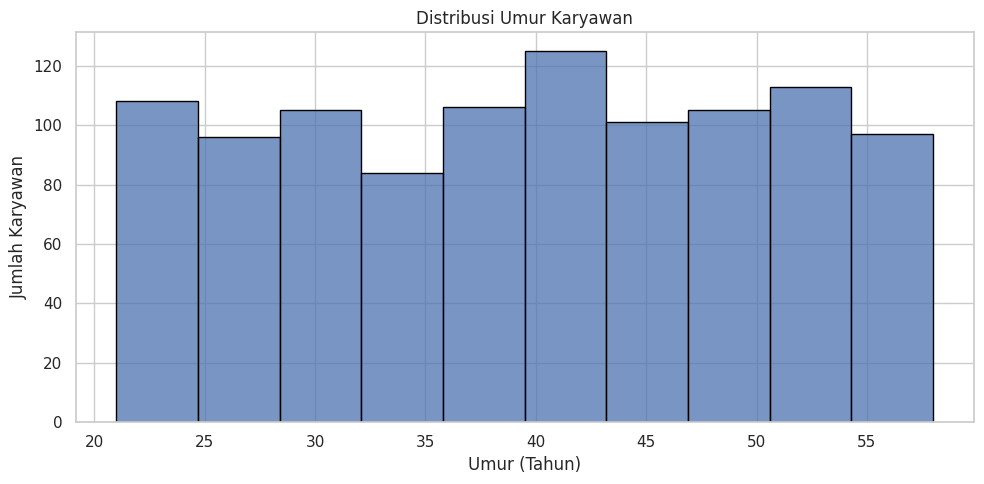

In [ ]:
# ============================================================
# BAGIAN D — VISUALISASI DISTRIBUSI DATA
#
# CELL 6 — HISTOGRAM DISTRIBUSI UMUR
#
# Tujuan:
# Memvisualisasikan distribusi umur karyawan.
#
# HISTOGRAM:
#
# Histogram digunakan untuk menggambarkan
# distribusi variabel numerik.
#
# Sumbu X:
# Interval nilai numerik.
#
# Sumbu Y:
# Jumlah observasi dalam setiap interval.
#
# Histogram dapat membantu mengidentifikasi:
#
# - Rentang nilai yang paling sering muncul.
# - Persebaran data.
# - Kemencengan distribusi.
# - Kemungkinan nilai ekstrem.
# ============================================================


# Mengatur ukuran grafik.
#
# figsize=(10, 5):
# Lebar 10 inci dan tinggi 5 inci.
plt.figure(figsize=(10, 5))


# Membuat histogram menggunakan Seaborn.
#
# data=df:
# Dataset yang digunakan.
#
# x='Umur':
# Variabel yang divisualisasikan.
#
# bins=10:
# Membagi rentang umur menjadi 10 interval.
#
# edgecolor='black':
# Memberikan garis pembatas pada setiap batang.
sns.histplot(
    data=df,
    x='Umur',
    bins=10,
    edgecolor='black'
)


# Menambahkan judul.
plt.title('Distribusi Umur Karyawan')


# Menambahkan label sumbu X.
plt.xlabel('Umur (Tahun)')


# Menambahkan label sumbu Y.
plt.ylabel('Jumlah Karyawan')


# Menyesuaikan tata letak grafik.
plt.tight_layout()


# Menampilkan grafik.
plt.show()


# ============================================================
# CARA MEMBACA HISTOGRAM
# ============================================================
#
# Setiap batang menunjukkan jumlah karyawan
# dalam interval umur tertentu.
#
# Batang yang tinggi menunjukkan bahwa banyak
# karyawan berada pada rentang umur tersebut.
#
# Perhatikan:
#
# 1. Di rentang umur berapa batang paling tinggi?
#
# 2. Apakah distribusi terlihat relatif simetris?
#
# 3. Apakah sebagian besar data terkonsentrasi
#    pada rentang tertentu?
#
# 4. Apakah terdapat nilai umur yang jauh
#    dari sebagian besar observasi?
#
#
# PERTANYAAN DISKUSI:
#
# Bagaimana karakteristik distribusi umur karyawan
# berdasarkan histogram yang dihasilkan?
#
# ============================================================

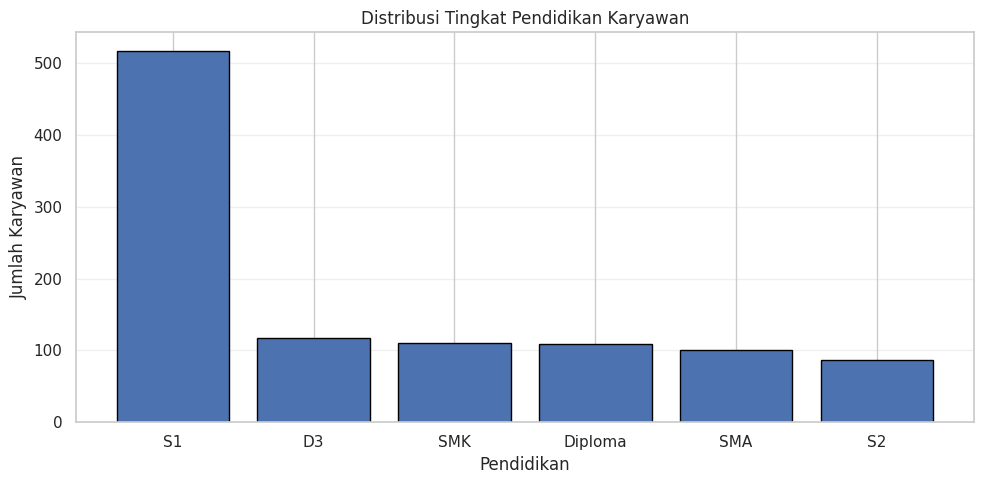

In [ ]:
# ============================================================
# BAGIAN D — VISUALISASI DISTRIBUSI DATA
#
# CELL 7 — DIAGRAM BATANG PENDIDIKAN
#
# Tujuan:
# Menampilkan jumlah karyawan berdasarkan pendidikan.
#
# DIAGRAM BATANG:
#
# Digunakan untuk membandingkan nilai
# atau frekuensi antar kategori.
#
# Perbedaan dengan histogram:
#
# Histogram:
# - Digunakan untuk distribusi numerik.
# - Batang menunjukkan interval nilai.
#
# Diagram batang:
# - Digunakan untuk kategori.
# - Setiap batang mewakili kategori tertentu.
# ============================================================


# Menghitung jumlah setiap tingkat pendidikan.
jumlah_pendidikan = df['Pendidikan'].value_counts()


# Menentukan ukuran grafik.
plt.figure(figsize=(10, 5))


# Membuat diagram batang.
#
# x:
# Nama kategori pendidikan.
#
# y:
# Jumlah karyawan pada setiap kategori.
plt.bar(
    jumlah_pendidikan.index,
    jumlah_pendidikan.values,
    edgecolor='black'
)


# Menambahkan judul.
plt.title('Distribusi Tingkat Pendidikan Karyawan')


# Menambahkan label sumbu X.
plt.xlabel('Pendidikan')


# Menambahkan label sumbu Y.
plt.ylabel('Jumlah Karyawan')


# Menampilkan garis bantu horizontal.
#
# alpha=0.3:
# Mengatur tingkat transparansi garis.
plt.grid(axis='y', alpha=0.3)


# Menyesuaikan tata letak.
plt.tight_layout()


# Menampilkan grafik.
plt.show()


# ============================================================
# CARA MEMBACA DIAGRAM BATANG
# ============================================================
#
# Setiap batang mewakili satu kategori pendidikan.
#
# Semakin tinggi batang, semakin banyak
# karyawan pada kategori tersebut.
#
# Kita dapat membandingkan:
#
# - Pendidikan dengan frekuensi tertinggi.
# - Pendidikan dengan frekuensi terendah.
# - Perbedaan jumlah antar kategori.
#
#
# PERTANYAAN DISKUSI:
#
# 1. Pendidikan apa yang memiliki jumlah terbanyak?
#
# 2. Apakah distribusi pendidikan terlihat merata?
#
# 3. Mengapa histogram kurang sesuai jika digunakan
#    untuk variabel Pendidikan?
#
# ============================================================

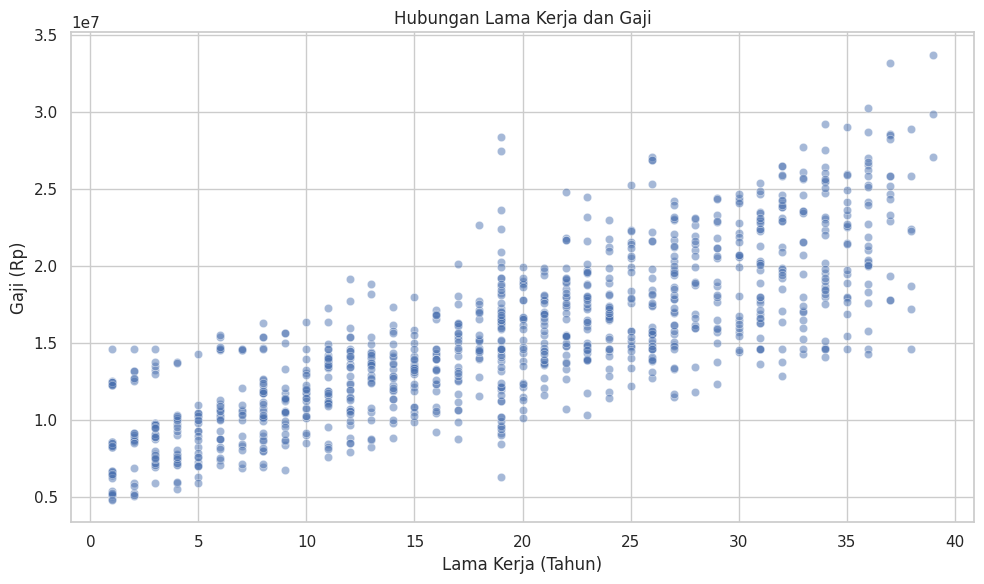

In [ ]:
# ============================================================
# BAGIAN E — MENCARI POLA DAN HUBUNGAN DATA
#
# CELL 8 — SCATTER PLOT
#
# Tujuan:
# Mengidentifikasi pola hubungan antara
# pengalaman kerja dan gaji karyawan.
#
# SCATTER PLOT:
#
# Merupakan grafik yang menampilkan hubungan
# antara dua variabel numerik.
#
# Setiap titik merepresentasikan satu observasi.
#
# Sumbu X:
# Lama kerja.
#
# Sumbu Y:
# Gaji.
#
# Pola yang mungkin ditemukan:
#
# 1. Positif:
#    Ketika X meningkat, Y cenderung meningkat.
#
# 2. Negatif:
#    Ketika X meningkat, Y cenderung menurun.
#
# 3. Tidak ada pola linear yang jelas.
# ============================================================


# Mengatur ukuran grafik.
plt.figure(figsize=(10, 6))


# Membuat scatter plot.
#
# alpha=0.5:
# Membuat titik agak transparan.
#
# Transparansi membantu memperlihatkan
# area dengan banyak titik yang bertumpuk.
sns.scatterplot(
    data=df,
    x='Lama_Kerja',
    y='Gaji',
    alpha=0.5
)


# Memberikan judul.
plt.title('Hubungan Lama Kerja dan Gaji')


# Memberikan label sumbu X.
plt.xlabel('Lama Kerja (Tahun)')


# Memberikan label sumbu Y.
plt.ylabel('Gaji (Rp)')


# Menyesuaikan tata letak.
plt.tight_layout()


# Menampilkan grafik.
plt.show()


# ============================================================
# CARA MEMBACA SCATTER PLOT
# ============================================================
#
# Perhatikan arah persebaran titik.
#
# Jika titik cenderung bergerak dari kiri bawah
# menuju kanan atas:
#
# Terdapat indikasi hubungan positif.
#
# Jika titik cenderung bergerak dari kiri atas
# menuju kanan bawah:
#
# Terdapat indikasi hubungan negatif.
#
# Apabila titik tersebar tanpa pola tertentu:
#
# Tidak terlihat hubungan linear yang jelas.
#
#
# CATATAN:
#
# Scatter plot hanya membantu kita mengamati pola.
#
# Untuk mengukur kekuatan hubungan linear,
# kita dapat menghitung korelasi Pearson.
#
# Korelasi tidak membuktikan hubungan sebab-akibat.
#
#
# PERTANYAAN DISKUSI:
#
# Apakah pengalaman kerja yang lebih lama
# cenderung berkaitan dengan gaji lebih tinggi?
#
# ============================================================

Matriks Korelasi:


,Umur,Lama_Kerja,Gaji
Umur,1.00,0.97,0.81
Lama_Kerja,0.97,1.00,0.80
Gaji,0.81,0.80,1.00


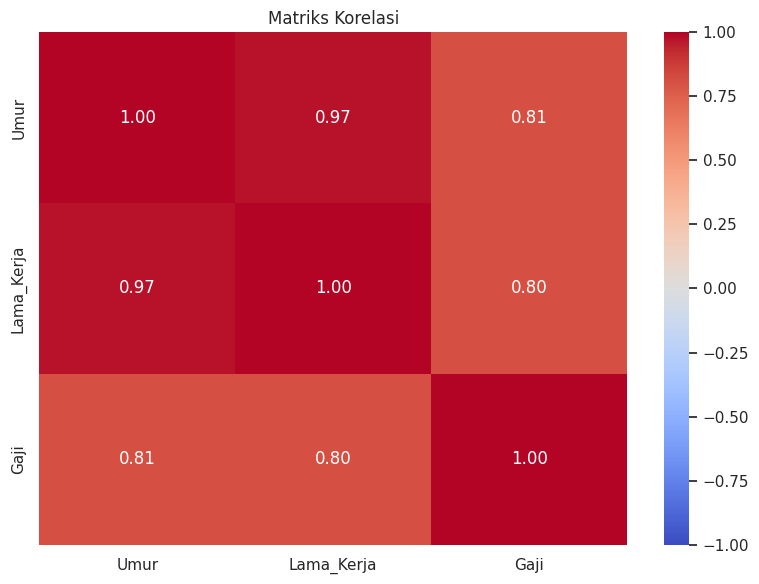

In [ ]:
# ============================================================
# BAGIAN E — MENCARI POLA DAN HUBUNGAN DATA
#
# CELL 9 — ANALISIS KORELASI
#
# Tujuan:
# Mengukur arah dan kekuatan hubungan linear
# antarvariabel numerik.
#
# KORELASI PEARSON:
#
# Koefisien korelasi memiliki rentang -1 hingga +1.
#
# Nilai mendekati +1:
# Hubungan linear positif yang kuat.
#
# Nilai mendekati 0:
# Hubungan linear lemah atau tidak ada.
#
# Nilai mendekati -1:
# Hubungan linear negatif yang kuat.
#
# PENTING:
#
# Korelasi tidak membuktikan hubungan sebab-akibat.
#
# Hubungan yang tidak linear juga mungkin tidak
# terdeteksi dengan baik oleh korelasi Pearson.
# ============================================================


# Memilih variabel numerik untuk dianalisis.
#
# ID tidak dimasukkan karena merupakan identitas.
kolom_korelasi = [
    'Umur',
    'Lama_Kerja',
    'Gaji'
]


# Menghitung korelasi Pearson.
#
# corr() menghasilkan matriks korelasi.
matriks_korelasi = df[kolom_korelasi].corr(
    method='pearson'
)


# Menampilkan matriks korelasi.
#
# round(2):
# Membulatkan hasil menjadi dua angka desimal.
print("Matriks Korelasi:")

display(matriks_korelasi.round(2))


# ============================================================
# VISUALISASI MENGGUNAKAN HEATMAP
# ============================================================


# Menentukan ukuran grafik.
plt.figure(figsize=(8, 6))


# Membuat heatmap.
#
# annot=True:
# Menampilkan angka pada setiap kotak.
#
# fmt='.2f':
# Menampilkan dua angka desimal.
#
# vmin=-1 dan vmax=1:
# Menentukan batas skala korelasi.
sns.heatmap(
    matriks_korelasi,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)


# Menambahkan judul.
plt.title('Matriks Korelasi')


# Menyesuaikan tata letak.
plt.tight_layout()


# Menampilkan grafik.
plt.show()


# ============================================================
# CARA MEMBACA HEATMAP
# ============================================================
#
# Setiap kotak menunjukkan korelasi
# antara dua variabel.
#
# Angka 1 pada diagonal menunjukkan korelasi
# suatu variabel dengan dirinya sendiri.
#
# Contoh hipotetis:
#
# Korelasi Lama_Kerja dan Gaji = 0.75.
#
# Artinya terdapat hubungan linear positif
# yang cukup kuat pada dataset tersebut.
#
# Namun, kita tidak boleh menyimpulkan bahwa
# menambah pengalaman kerja pasti menyebabkan
# kenaikan gaji.
#
#
# PERTANYAAN DISKUSI:
#
# 1. Variabel apa yang memiliki korelasi
#    paling tinggi dengan Gaji?
#
# 2. Bagaimana hubungan Umur dan Lama_Kerja?
#
# 3. Mengapa korelasi tidak dapat langsung
#    dianggap sebagai hubungan sebab-akibat?
#
# ============================================================

Statistik Gaji berdasarkan Pendidikan:


,count,mean,median,min,max
Pendidikan,,,,,
S2,86,"18,749,250.00","17,435,500.00","12,257,000.00","33,711,000.00"
S1,517,"15,994,266.00","15,409,000.00","8,268,000.00","29,834,000.00"
Diploma,109,"14,708,445.00","14,364,000.00","6,487,000.00","27,038,000.00"
D3,117,"13,310,376.00","13,299,000.00","6,269,000.00","27,005,000.00"
SMA,101,"12,931,035.00","12,843,000.00","4,814,000.00","25,166,000.00"
SMK,110,"12,891,227.00","13,363,000.00","5,109,000.00","26,222,000.00"


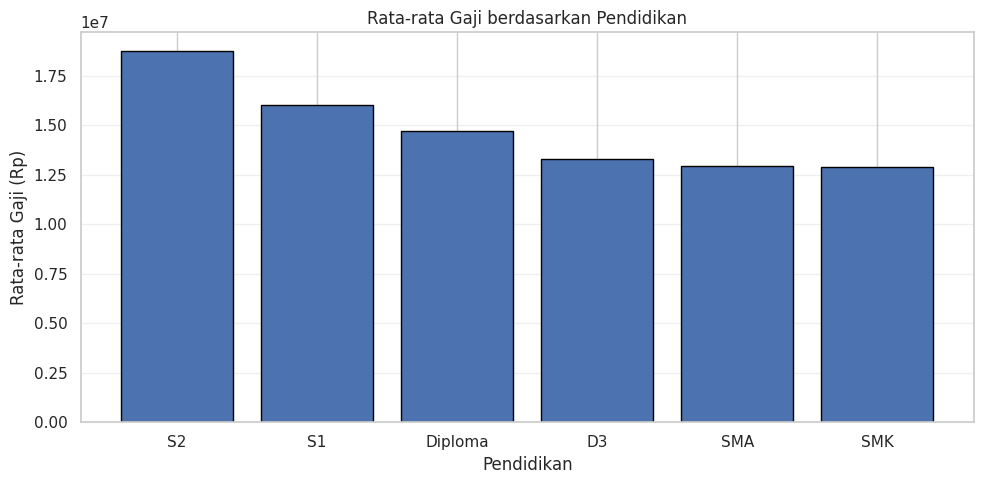

In [ ]:
# ============================================================
# BAGIAN F — ANALISIS BERDASARKAN KELOMPOK
#
# CELL 10 — ANALISIS MENGGUNAKAN GROUPBY
#
# Tujuan:
# Membandingkan karakteristik gaji
# berdasarkan tingkat pendidikan.
#
# GROUPBY:
#
# groupby() merupakan fitur Pandas untuk
# mengelompokkan data berdasarkan kategori.
#
# Kita dapat menghitung statistik secara terpisah
# untuk setiap kelompok.
#
# Contoh:
#
# Rata-rata gaji karyawan SMA.
# Rata-rata gaji karyawan SMK.
# Rata-rata gaji karyawan S1.
# Rata-rata gaji karyawan S2.
# ============================================================


# ============================================================
# 1. MENGELOMPOKKAN DATA
# ============================================================


# Mengelompokkan data berdasarkan Pendidikan.
#
# Kemudian menghitung statistik kolom Gaji.
#
# count  = jumlah data.
# mean   = rata-rata.
# median = nilai tengah.
# min    = nilai minimum.
# max    = nilai maksimum.
statistik_pendidikan = (
    df.groupby('Pendidikan')['Gaji']
    .agg([
        'count',
        'mean',
        'median',
        'min',
        'max'
    ])
)


# Mengurutkan berdasarkan rata-rata gaji.
#
# ascending=False:
# Mengurutkan dari nilai tertinggi ke terendah.
statistik_pendidikan = statistik_pendidikan.sort_values(
    by='mean',
    ascending=False
)


# Menampilkan hasil.
print("Statistik Gaji berdasarkan Pendidikan:")

display(statistik_pendidikan.round(0))


# ============================================================
# 2. VISUALISASI HASIL
# ============================================================


# Menentukan ukuran grafik.
plt.figure(figsize=(10, 5))


# Membuat diagram batang rata-rata gaji.
#
# Setiap batang menunjukkan rata-rata gaji
# untuk satu kategori pendidikan.
plt.bar(
    statistik_pendidikan.index,
    statistik_pendidikan['mean'],
    edgecolor='black'
)


# Memberikan judul.
plt.title('Rata-rata Gaji berdasarkan Pendidikan')


# Memberikan label.
plt.xlabel('Pendidikan')

plt.ylabel('Rata-rata Gaji (Rp)')


# Menampilkan garis bantu.
plt.grid(axis='y', alpha=0.3)


# Menyesuaikan tata letak.
plt.tight_layout()


# Menampilkan grafik.
plt.show()


# ============================================================
# CARA MEMBACA HASIL
# ============================================================
#
# Tabel menunjukkan:
#
# - Jumlah karyawan dalam setiap kelompok.
# - Rata-rata gaji setiap kelompok.
# - Median gaji setiap kelompok.
# - Gaji minimum.
# - Gaji maksimum.
#
# Diagram batang memudahkan perbandingan
# rata-rata gaji antar kategori.
#
#
# CATATAN PENTING:
#
# Dataset yang kita gunakan bersifat sintetis.
#
# Saat pembuatan dataset, gaji dasar memang
# ditentukan berdasarkan tingkat pendidikan.
#
# Oleh karena itu, hubungan yang ditemukan
# mencerminkan aturan pembuatan data.
#
# Hasil ini bukan bukti hubungan sebab-akibat
# pada populasi pekerja sebenarnya.
#
#
# PERTANYAAN DISKUSI:
#
# 1. Bagaimana perbedaan rata-rata gaji
#    antar tingkat pendidikan?
#
# 2. Apakah kelompok dengan rata-rata tertinggi
#    juga mempunyai jumlah karyawan terbanyak?
#
# 3. Apa perbedaan mean dan median
#    untuk setiap kelompok pendidikan?
#
# ============================================================

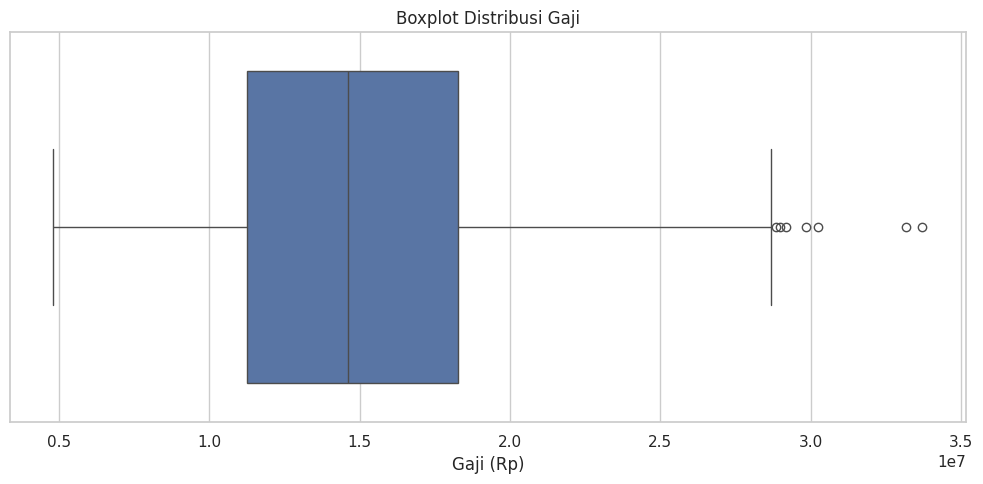

In [ ]:
# ============================================================
# BAGIAN G — MENDETEKSI ANOMALI
#
# CELL 11 — BOXPLOT
#
# Tujuan:
# Mengidentifikasi potensi outlier
# berdasarkan distribusi gaji.
#
# BOXPLOT:
#
# Visualisasi yang menunjukkan:
#
# - Median.
# - Kuartil pertama (Q1).
# - Kuartil ketiga (Q3).
# - Interquartile Range (IQR).
# - Whisker.
# - Observasi di luar whisker.
#
# IQR = Q3 - Q1.
#
# Boxplot dapat membantu menemukan
# observasi yang jauh dari sebagian besar data.
#
# CATATAN:
#
# Observasi yang terdeteksi sebagai outlier
# belum tentu merupakan kesalahan data.
# ============================================================


# Menentukan ukuran grafik.
plt.figure(figsize=(10, 5))


# Membuat boxplot kolom Gaji.
#
# Sumbu X menunjukkan nilai gaji.
sns.boxplot(
    data=df,
    x='Gaji'
)


# Memberikan judul.
plt.title('Boxplot Distribusi Gaji')


# Memberikan label sumbu X.
plt.xlabel('Gaji (Rp)')


# Menyesuaikan tata letak.
plt.tight_layout()


# Menampilkan grafik.
plt.show()


# ============================================================
# CARA MEMBACA BOXPLOT
# ============================================================
#
# Garis di dalam kotak:
# Menunjukkan median.
#
# Batas kiri dan kanan kotak:
# Menunjukkan Q1 dan Q3.
#
# Panjang kotak:
# Menunjukkan rentang 50% data bagian tengah.
#
# Whisker:
# Menunjukkan rentang nilai berdasarkan
# aturan boxplot.
#
# Titik di luar whisker:
# Menunjukkan kandidat outlier.
#
#
# PERTANYAAN DISKUSI:
#
# 1. Apakah terdapat kandidat outlier?
#
# 2. Bagaimana penyebaran data gaji?
#
# 3. Mengapa kita tidak boleh langsung
#    menghapus semua outlier?
#
# ============================================================

In [ ]:
# ============================================================
# BAGIAN G — MENDETEKSI ANOMALI
#
# CELL 12 — METODE INTERQUARTILE RANGE (IQR)
#
# Tujuan:
# Mendeteksi kandidat outlier secara numerik
# menggunakan metode IQR.
#
# RUMUS:
#
# IQR = Q3 - Q1.
#
# Batas bawah = Q1 - 1.5 * IQR.
#
# Batas atas  = Q3 + 1.5 * IQR.
#
# Observasi di luar batas tersebut
# ditandai sebagai kandidat outlier.
#
# Penting:
#
# Deteksi outlier berbeda dari menghapus outlier.
#
# Pada tahap EDA, kita hanya melakukan identifikasi
# dan pemeriksaan terhadap nilai yang terdeteksi.
# ============================================================


# ============================================================
# 1. MENGHITUNG KUARTIL
# ============================================================


# Menghitung Q1 atau persentil ke-25.
Q1 = df['Gaji'].quantile(0.25)


# Menghitung Q3 atau persentil ke-75.
Q3 = df['Gaji'].quantile(0.75)


# Menghitung IQR.
IQR = Q3 - Q1


# ============================================================
# 2. MENGHITUNG BATAS OUTLIER
# ============================================================


# Batas bawah berdasarkan metode IQR.
batas_bawah = Q1 - (1.5 * IQR)


# Batas atas berdasarkan metode IQR.
batas_atas = Q3 + (1.5 * IQR)


# Menampilkan hasil.
print("HASIL PERHITUNGAN IQR")

print(f"Q1          : Rp{Q1:,.0f}")

print(f"Q3          : Rp{Q3:,.0f}")

print(f"IQR         : Rp{IQR:,.0f}")

print(f"Batas Bawah : Rp{batas_bawah:,.0f}")

print(f"Batas Atas  : Rp{batas_atas:,.0f}")


# ============================================================
# 3. IDENTIFIKASI KANDIDAT OUTLIER
# ============================================================


# Mengambil baris yang memiliki nilai gaji:
#
# - Di bawah batas bawah.
# ATAU
# - Di atas batas atas.
#
# Simbol | berarti OR.
anomali = df[
    (df['Gaji'] < batas_bawah) |
    (df['Gaji'] > batas_atas)
]


# Menghitung jumlah kandidat outlier.
jumlah_anomali = len(anomali)


# Menghitung persentase kandidat outlier.
persentase_anomali = (
    jumlah_anomali / len(df)
) * 100


# Menampilkan hasil.
print("\nJUMLAH KANDIDAT OUTLIER")

print(f"Jumlah     : {jumlah_anomali}")

print(f"Persentase : {persentase_anomali:.2f}%")


# Menampilkan data kandidat outlier.
print("\nData yang terdeteksi:")

display(
    anomali[
        [
            'Umur',
            'Pendidikan',
            'Lama_Kerja',
            'Gaji'
        ]
    ]
)


# ============================================================
# CARA MEMBACA HASIL
# ============================================================
#
# Q1:
# Nilai yang membatasi 25% bagian bawah distribusi.
#
# Q3:
# Nilai yang membatasi 75% bagian bawah distribusi.
#
# IQR:
# Rentang antara Q1 dan Q3.
#
# Batas bawah dan batas atas:
# Digunakan sebagai aturan statistik
# untuk mengidentifikasi kandidat outlier.
#
#
# CATATAN:
#
# Karena data sudah dibersihkan pada Pertemuan 3,
# beberapa nilai ekstrem yang sengaja dibuat
# mungkin sudah diperbaiki.
#
# Meskipun demikian, metode IQR masih dapat
# mendeteksi observasi yang berbeda secara statistik.
#
# Hal tersebut tidak otomatis berarti data salah.
#
#
# PERTANYAAN DISKUSI:
#
# 1. Berapa jumlah kandidat outlier yang ditemukan?
#
# 2. Berapa persentasenya?
#
# 3. Apakah kandidat outlier memiliki karakteristik
#    pendidikan atau lama kerja tertentu?
#
# 4. Apakah kandidat outlier perlu dihapus?
#    Jelaskan alasannya.
#
# ============================================================

HASIL PERHITUNGAN IQR
Q1          : Rp11,253,000
Q3          : Rp18,257,750
IQR         : Rp7,004,750
Batas Bawah : Rp745,875
Batas Atas  : Rp28,764,875

JUMLAH KANDIDAT OUTLIER
Jumlah     : 7
Persentase : 0.67%

Data yang terdeteksi:


,Umur,Pendidikan,Lama_Kerja,Gaji
53,57.00,S2,37.00,"33,169,000.00"
564,54.00,S2,34.00,"29,195,000.00"
619,58.00,S1,39.00,"29,834,000.00"
651,58.00,S2,39.00,"33,711,000.00"
695,55.00,S1,35.00,"28,983,000.00"
797,57.00,S2,36.00,"30,236,000.00"
1028,58.00,S1,38.00,"28,860,000.00"


In [ ]:
# ============================================================
# BAGIAN H — MENYUSUN KESIMPULAN
#
# CELL 13 — RANGKUMAN HASIL EDA
#
# Tujuan:
# Menggabungkan beberapa hasil analisis
# menjadi satu rangkuman yang mudah dibaca.
#
# Kita akan menampilkan:
#
# 1. Jumlah observasi.
# 2. Rata-rata umur.
# 3. Median gaji.
# 4. Pendidikan paling sering muncul.
# 5. Korelasi lama kerja dan gaji.
# 6. Jumlah kandidat outlier.
# 7. Persentase kandidat outlier.
#
# Rangkuman ini merupakan data hasil analisis.
#
# Mahasiswa tetap perlu menjelaskan
# makna dari setiap temuan.
# ============================================================


# Menghitung jumlah observasi.
jumlah_data = len(df)


# Menghitung rata-rata umur.
rata_umur = df['Umur'].mean()


# Menghitung median gaji.
median_gaji = df['Gaji'].median()


# Mengambil modus pendidikan.
pendidikan_terbanyak = df['Pendidikan'].mode()[0]


# Menghitung korelasi lama kerja dan gaji.
korelasi = df['Lama_Kerja'].corr(df['Gaji'])


# Menghitung jumlah kandidat outlier.
jumlah_anomali = len(anomali)


# Menghitung persentase kandidat outlier.
persentase_anomali = (
    jumlah_anomali / jumlah_data
) * 100


# ============================================================
# MENAMPILKAN RANGKUMAN
# ============================================================


# Membuat garis pembatas.
print("=" * 55)


# Menampilkan judul.
print("RANGKUMAN EXPLORATORY DATA ANALYSIS")


# Membuat garis pembatas.
print("=" * 55)


# Menampilkan jumlah data.
print(f"Jumlah Data          : {jumlah_data}")


# Menampilkan rata-rata umur.
print(f"Rata-rata Umur       : {rata_umur:.2f} tahun")


# Menampilkan median gaji.
print(f"Median Gaji          : Rp{median_gaji:,.0f}")


# Menampilkan modus pendidikan.
print(f"Pendidikan Terbanyak : {pendidikan_terbanyak}")


# Menampilkan korelasi.
print(f"Korelasi Kerja-Gaji  : {korelasi:.2f}")


# Menampilkan jumlah kandidat outlier.
print(f"Potensi Anomali      : {jumlah_anomali} data")


# Menampilkan persentase kandidat outlier.
print(f"Persentase Anomali   : {persentase_anomali:.2f}%")


# Garis penutup.
print("=" * 55)


# ============================================================
# CARA MENGINTERPRETASIKAN RANGKUMAN
# ============================================================
#
# Perhatikan setiap hasil yang diperoleh.
#
# JUMLAH DATA:
# Banyaknya observasi yang dianalisis.
#
# RATA-RATA UMUR:
# Menggambarkan rata-rata usia dalam dataset.
#
# MEDIAN GAJI:
# Menunjukkan nilai tengah distribusi gaji.
#
# PENDIDIKAN TERBANYAK:
# Kategori pendidikan dengan frekuensi terbesar.
#
# KORELASI:
# Mengukur hubungan linear antara
# pengalaman kerja dan gaji.
#
# POTENSI ANOMALI:
# Jumlah observasi yang berada di luar
# batas statistik metode IQR.
#
#
# PERTANYAAN DISKUSI:
#
# Berdasarkan seluruh hasil analisis,
# sebutkan tiga temuan utama dari dataset.
#
# Setiap temuan harus didukung dengan
# hasil statistik atau visualisasi.
#
# ============================================================

RANGKUMAN EXPLORATORY DATA ANALYSIS
Jumlah Data          : 1040
Rata-rata Umur       : 39.71 tahun
Median Gaji          : Rp14,617,500
Pendidikan Terbanyak : S1
Korelasi Kerja-Gaji  : 0.80
Potensi Anomali      : 7 data
Persentase Anomali   : 0.67%


In [ ]:
# ============================================================
# BAGIAN I — MENYIMPAN HASIL PRAKTIKUM
#
# CELL 14 — EKSPOR HASIL EDA
#
# Tujuan:
# Menyimpan rangkuman hasil analisis
# ke Google Drive dalam format CSV.
#
# Mengapa hasil perlu disimpan?
#
# 1. Agar tidak hilang ketika sesi Colab berakhir.
#
# 2. Agar hasil dapat digunakan kembali.
#
# 3. Agar hasil dapat dilampirkan dalam laporan.
#
# 4. Agar analisis mudah didokumentasikan.
#
# CATATAN:
#
# File ini menyimpan angka rangkuman.
#
# Notebook dan grafik tetap perlu disimpan
# secara terpisah.
# ============================================================


# ============================================================
# 1. MEMBUAT TABEL RANGKUMAN
# ============================================================


# Membuat DataFrame yang berisi:
#
# Kolom Indikator:
# Nama statistik yang dihitung.
#
# Kolom Nilai:
# Hasil perhitungan statistik.
ringkasan = pd.DataFrame({

    'Indikator': [
        'Jumlah Data',
        'Rata-rata Umur',
        'Median Gaji',
        'Pendidikan Terbanyak',
        'Korelasi Lama Kerja dan Gaji',
        'Jumlah Potensi Anomali',
        'Persentase Potensi Anomali'
    ],

    'Nilai': [
        jumlah_data,
        rata_umur,
        median_gaji,
        pendidikan_terbanyak,
        korelasi,
        jumlah_anomali,
        persentase_anomali
    ]
})


# ============================================================
# 2. MENENTUKAN LOKASI PENYIMPANAN
# ============================================================


# Menggabungkan folder praktikum dengan nama file.
output_path = os.path.join(
    folder_path,
    'ringkasan_eda.csv'
)


# ============================================================
# 3. MENYIMPAN FILE
# ============================================================


# Mengubah DataFrame menjadi file CSV.
#
# index=False:
# Indeks DataFrame tidak ikut disimpan.
ringkasan.to_csv(
    output_path,
    index=False
)


# Menampilkan informasi.
print("✅ Rangkuman EDA berhasil disimpan.")

print(f"Lokasi file: {output_path}")


# Menampilkan hasil.
display(ringkasan)


# ============================================================
# CARA MEMERIKSA HASIL
# ============================================================
#
# 1. Buka Google Drive.
#
# 2. Masuk ke folder:
#    Praktikum_Literasi_Data_AI.
#
# 3. Cari file:
#    ringkasan_eda.csv.
#
# 4. Buka file untuk melihat hasil analisis.
#
#
# PENTING:
#
# Jangan lupa menyimpan notebook Google Colab.
#
# Jika notebook belum tersimpan di Google Drive,
# gunakan:
#
# File -> Save a copy in Drive.
#
# ============================================================

✅ Rangkuman EDA berhasil disimpan.
Lokasi file: /content/drive/MyDrive/Praktikum_Literasi_Data_AI/ringkasan_eda.csv


,Indikator,Nilai
0,Jumlah Data,1040
1,Rata-rata Umur,39.71
2,Median Gaji,"14,617,500.00"
3,Pendidikan Terbanyak,S1
4,Korelasi Lama Kerja dan Gaji,0.80
5,Jumlah Potensi Anomali,7
6,Persentase Potensi Anomali,0.67


In [ ]:
# ============================================================
# BAGIAN J — LATIHAN MANDIRI MAHASISWA
#
# CELL 15 — TUGAS DAN INTERPRETASI EDA
# ============================================================
#
# TUJUAN:
#
# Mengukur kemampuan mahasiswa dalam:
#
# 1. Membaca hasil analisis.
#
# 2. Menginterpretasikan statistik deskriptif.
#
# 3. Menginterpretasikan visualisasi.
#
# 4. Mengidentifikasi pola.
#
# 5. Mengidentifikasi potensi anomali.
#
# 6. Menyusun kesimpulan berdasarkan data.
#
#
# ============================================================
# TUGAS 1 — STATISTIK DESKRIPTIF
# ============================================================
#
# Berdasarkan dataset yang dianalisis:
#
# 1. Berapa rata-rata umur karyawan?
#
# 2. Berapa median gaji karyawan?
#
# 3. Berapa standar deviasi gaji?
#
# 4. Apakah rata-rata gaji lebih besar
#    daripada median gaji?
#
# 5. Apa kemungkinan penyebab perbedaan tersebut?
#
#
# ============================================================
# TUGAS 2 — DISTRIBUSI DATA
# ============================================================
#
# Berdasarkan histogram dan diagram batang:
#
# 1. Bagaimana distribusi umur karyawan?
#
# 2. Pendidikan apa yang paling sering ditemukan?
#
# 3. Berapa persentase kategori pendidikan tersebut?
#
# 4. Mengapa histogram digunakan untuk umur,
#    sedangkan diagram batang digunakan untuk pendidikan?
#
#
# ============================================================
# TUGAS 3 — ANALISIS HUBUNGAN
# ============================================================
#
# Berdasarkan scatter plot dan matriks korelasi:
#
# 1. Bagaimana pola hubungan lama kerja dan gaji?
#
# 2. Berapa nilai korelasinya?
#
# 3. Bagaimana arah hubungan tersebut?
#
# 4. Apakah korelasi membuktikan sebab-akibat?
#
# 5. Apa faktor lain yang mungkin memengaruhi
#    hubungan lama kerja dan gaji?
#
#
# ============================================================
# TUGAS 4 — ANALISIS BERDASARKAN KELOMPOK
# ============================================================
#
# Berdasarkan hasil groupby:
#
# 1. Bagaimana perbedaan rata-rata gaji
#    antar tingkat pendidikan?
#
# 2. Apakah kategori pendidikan dengan rata-rata
#    gaji tertinggi juga memiliki jumlah
#    karyawan terbanyak?
#
# 3. Bagaimana perbandingan mean dan median
#    pada setiap kelompok pendidikan?
#
#
# ============================================================
# TUGAS 5 — DETEKSI ANOMALI
# ============================================================
#
# Berdasarkan boxplot dan metode IQR:
#
# 1. Apakah ditemukan kandidat outlier?
#
# 2. Berapa jumlahnya?
#
# 3. Berapa persentasenya?
#
# 4. Apa karakteristik observasi
#    yang terdeteksi sebagai kandidat outlier?
#
# 5. Apakah seluruh kandidat outlier
#    seharusnya dihapus?
#
#    Jelaskan alasan berdasarkan konteks data.
#
#
# ============================================================
# TUGAS TAMBAHAN — ANALISIS MANDIRI
# ============================================================
#
# Pilih satu pertanyaan analisis baru
# yang belum dicontohkan dalam praktikum.
#
# Contoh:
#
# - Bagaimana distribusi gaji berdasarkan kota?
#
# - Bagaimana hubungan umur dan gaji?
#
# - Bagaimana persebaran pengalaman kerja
#   berdasarkan tingkat pendidikan?
#
# Mahasiswa harus:
#
# 1. Merumuskan pertanyaan analisis.
#
# 2. Memilih metode statistik yang sesuai.
#
# 3. Membuat visualisasi yang relevan.
#
# 4. Menjelaskan hasil.
#
# 5. Menarik kesimpulan berdasarkan data.
#
#
# ============================================================
# HASIL YANG HARUS DIKUMPULKAN
# ============================================================
#
# 1. Notebook Google Colab yang sudah dijalankan.
#
# 2. Laporan singkat hasil analisis.
#
# 3. Jawaban seluruh pertanyaan utama.
#
# 4. Satu analisis tambahan yang dibuat sendiri.
#
#
# ============================================================
# KESIMPULAN PEMBELAJARAN
# ============================================================
#
# Exploratory Data Analysis (EDA) merupakan proses
# mengeksplorasi dataset untuk memahami karakteristiknya.
#
# EDA membantu kita:
#
# - Mengenali struktur data.
#
# - Memahami distribusi data.
#
# - Menghitung statistik deskriptif.
#
# - Mengidentifikasi pola dan hubungan.
#
# - Mendeteksi potensi anomali.
#
# - Menentukan analisis lanjutan yang diperlukan.
#
# EDA bukan sekadar membuat grafik.
#
# EDA merupakan proses mengubah data
# menjadi informasi yang dapat diinterpretasikan.
#
# ============================================================